# Tabular Models Preparation & Training

## Setup

### Module Imports & Drive Mount

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import textwrap

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

from google.colab import userdata
GLIOMA_DIR = userdata.get('GLIOMA_DIR')

Mounted at /content/drive/


### Load Preprocessed Data

In [33]:
EDA_DIR = os.path.join(GLIOMA_DIR, 'eda')
os.makedirs(EDA_DIR, exist_ok=True)
preprocessed_dir = os.path.join(EDA_DIR, 'preprocessed')

X = pd.read_pickle(os.path.join(preprocessed_dir, 'X.pkl'))
y = pd.read_pickle(os.path.join(preprocessed_dir, 'y.pkl'))

print(f"Loaded X: {X.shape}")
print(f"Loaded y: {y.shape}")
print(f"\nTarget distribution:")
print(f"  Survived: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Died: {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

Loaded X: (203, 28)
Loaded y: (203,)

Target distribution:
  Survived: 106 (52.2%)
  Died: 97 (47.8%)


In [34]:
FIGURES_DIR = os.path.join(GLIOMA_DIR, 'tabular models', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Figures directory: {FIGURES_DIR}")

Figures directory: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/tabular models/figures


### Model & Comparison Imports

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import uniform, randint

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

### MODEL ARCHITECTURE CHOICE: XGBoost


Why XGBoost?

1. Small Dataset (203 patients)
   - XGBoost excels with 100s-10,000s samples
   - Deep learning needs 10,000+ samples
   
2. Heterogenous Features
   - Mix of categorical (sex, race, diagnosis) and numeric (age, days, molecular markers)
   - XGBoost handles mixed types natively
   - No feature scaling required
   
3. Missing Data
   - XGBoost handles NaN values automatically during training
   - No imputation needed for remaining missing values
   
4. Evaluate Feature Importance (Key Goal Here)
   - Built-in feature importance via gain, split count, or SHAP
   - Critical for your two-stage workflow: baseline → feature selection → focused model
   
5. Robust to Overfitting
   - Regularization parameters (lambda, alpha)
   - Max depth limits tree complexity
   - Subsampling provides natural regularization
   
6. Class Balance
   - Your dataset is 52% alive / 48% died (balanced)
   - No special class weighting needed, but XGBoost supports scale_pos_weight if needed
   
7. Proven Performance
   - State-of-the-art for tabular medical data
   - Widely used in clinical ML research
   
Alternatives considered:
- Random Forest: Similar but slightly lower performance than XGBoost
- Logistic Regression: Assumes linear relationships (too simplistic for glioma biology)
- Neural Networks: Need 10x more data, harder to interpret
- LightGBM: Comparable to XGBoost, slightly faster but less tested in medical domain

Decision: XGBoost is optimal for out dataset size, feature types, and with the goal of feature importance extraction in mind.

## Train XGBoost with 5-fold stratified cross-validation

Cast object columns to category dtype

In [36]:
# XGBoost requires categorical columns to be pandas 'category' dtype, not 'object'
categorical_cols = ['sex at birth', 'race', 'primary diagnosis', 'previous brain tumor']

for col in categorical_cols:
    X[col] = X[col].astype('category')

print("✓ Categorical columns converted to category dtype")
print(f"Updated dtypes: {X[categorical_cols].dtypes.to_dict()}")

✓ Categorical columns converted to category dtype
Updated dtypes: {'sex at birth': CategoricalDtype(categories=['Female', 'Male'], ordered=False, categories_dtype=object), 'race': CategoricalDtype(categories=['Asian', 'Black or African American', 'Unknown', 'White'], ordered=False, categories_dtype=object), 'primary diagnosis': CategoricalDtype(categories=['Astrocytoma', 'Diffuse glioma', 'GBM',
                  'Glioma w/ GBM features', 'Oligodendro-glioma',
                  'Pilocytic astrocytoma'],
, ordered=False, categories_dtype=object), 'previous brain tumor': CategoricalDtype(categories=['No', 'Yes'], ordered=False, categories_dtype=object)}


#### GliomaBinarySurvivalModel() Class & Randomised Search Functions

#### Create GliomaBinarySurvivalModel Class

In [37]:
class GliomaBinarySurvivalModel:
    def __init__(self, name="Model", params=None, random_state=42, **kwargs):
        """
        name: str
            Model identifier
        params: dict, optional
            Complete parameter dictionary for XGBoost
        random_state: int
            Random seed for reproducibility
        **kwargs: optional
            Individual XGBoost parameters (e.g., max_depth=5, learning_rate=0.05)
        """
        self.name = name
        self.random_state = random_state
        self.model = None
        self.cv_results = None
        self.feature_importance = None
        self.X_train = None  # Store for later reference

        # Default hyperparameters
        default_params = {
            'n_estimators': 150,
            'max_depth': 5,
            'learning_rate': 0.05,
            'subsample': 0.75,
            'colsample_bytree': 1,
            'random_state': random_state,
            'enable_categorical': True,
            'eval_metric': 'logloss'
        }

        # Merge params: defaults <- full params dict <- individual kwargs
        if params is not None:
            default_params.update(params)
        if kwargs:
            default_params.update(kwargs)
        self.params = default_params

    def train_with_cv(self, X, y, cv_folds=5):
        """
        Train with stratified cross-validation
        Parameters:
        X: DataFrame of Features
        y: Series -> Target variable
        cv_folds: int -> Number of cross-validation folds (default: 5)
        """

        self.X_train = X  # Store for feature names
        print(f"\n{'='*70}")
        print(f"Training: {self.name}")
        print(f"{'='*70}")
        print(f"Dataset: {len(X)} patients × {X.shape[1]} features")
        print(f"Target: {(y==0).sum()} alive ({(y==0).sum()/len(y)*100:.1f}%), "
              f"{(y==1).sum()} died ({(y==1).sum()/len(y)*100:.1f}%)")

        # Check class balance
        balance_ratio = min((y==0).sum(), (y==1).sum()) / max((y==0).sum(), (y==1).sum())
        if balance_ratio < 0.3:
            print(f"⚠️  Warning: Imbalanced classes (ratio: {balance_ratio:.2f})")

        # Initialise model & set up CV
        self.model = XGBClassifier(**self.params)
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)
        scoring = {
            'accuracy': make_scorer(accuracy_score),
            'roc_auc': make_scorer(roc_auc_score),
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score),
            'f1': make_scorer(f1_score)
        }

        # Cross-validate
        print(f"\nRunning {cv_folds}-fold stratified cross-validation...")
        self.cv_results = cross_validate(
            self.model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1,
            verbose=3
        )

        # Print results
        self._print_cv_results()

        # Train final model on full data
        print("\nTraining final model on full dataset...")
        self.model.fit(X, y)

        # Extract feature importance
        self.feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        print(f"✓ Model trained successfully\n")

    def _print_cv_results(self):
        """Print formatted CV results"""
        print(f"\n{'Cross-Validation Results':^70}")
        print("-"*70)
        print(f"{'Metric':<15} {'Mean':<12} {'Std Dev':<12} {'Range'}")
        print("-"*70)
        for metric in ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']:
            scores = self.cv_results[f'test_{metric}']
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            min_score = np.min(scores)
            max_score = np.max(scores)
            print(f"{metric.upper():<15} {mean_score:.4f}       ±{std_score:.4f}      "
                  f"[{min_score:.3f}-{max_score:.3f}]")
        print()

    def get_top_features(self, n=None, importance_threshold=None):
        """
        Get top N most important features or features by cumulative importance threshold.

        Parameters:

        n: int, optional
            Number of top features to return (default: None).
        importance_threshold : float, optional
            Cumulative importance threshold (0 to 1) to select features (default: None).
            If provided, 'n' is ignored.

        Returns:

        pd.DataFrame
            Df containing the selected features and their importance.
            Returns None if model is not trained or no valid parameters provided.
        """

        if self.feature_importance is None:
            print("⚠️  Model not trained yet. Run train_with_cv() first.")
            return None

        # If we want threshold importance
        if importance_threshold is not None:
            if not 0 <= importance_threshold <= 1:
                print("⚠️  importance_threshold must be between 0 and 1.")
                return None

            # Calculate cumulative importance & select features up to threshold
            cumulative_importance = self.feature_importance['importance'].cumsum() / self.feature_importance['importance'].sum()
            selected_features = self.feature_importance[cumulative_importance <= importance_threshold]

            return selected_features

        # If we want top n features
        elif n is not None and n > 0:
            return self.feature_importance.head(n)
        else:
            print("⚠️  Please provide either 'n' (number of features) or 'importance_threshold'.")
            return None

    def plot_feature_importance(self, top_n=20, figsize=(12, 10), save_path=None, importance_threshold=None):
        """
        Plot top N most important features or features by cumulative importance threshold.

        Parameters:

        top_n : int, optional
            Number of top features to plot (default: 20). Ignored if importance_threshold is provided.
        figsize : tuple
            Figure size (width, height)
        save_path : str, optional
            Path to save figure (e.g., 'feature_importance.png')
        importance_threshold : float, optional
            Cumulative importance threshold (0 to 1) to select features for plotting (default: None).
        """
        if self.feature_importance is None:
            print("⚠️  Model not trained yet. Run train_with_cv() first.")
            return

        if importance_threshold is not None:
             top_features = self.get_top_features(importance_threshold=importance_threshold)
             title_suffix = f" (Cumulative Importance >= {importance_threshold*100:.0f}%)"
        else:
            top_features = self.get_top_features(n=top_n)
            title_suffix = f" (Top {top_n})"


        if top_features is None or top_features.empty:
             print("⚠️  No features selected based on provided criteria.")
             return

        fig, ax = plt.subplots(figsize=figsize)

        bars = ax.barh(
            range(len(top_features)),
            top_features['importance'].values,
            color=sns.color_palette("viridis", len(top_features)) # Use length of selected features
        )
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['feature'].values, fontsize=10)
        ax.set_xlabel('Importance (Gain)', fontsize=12, fontweight='bold')
        ax.set_title(
            f'Most Important Features\n{self.name} - XGBoost Feature Importance' + title_suffix,
            fontsize=14,
            fontweight='bold'
        )
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, (idx, row) in enumerate(top_features.iterrows()):
            ax.text(
                row['importance'],
                i,
                f" {row['importance']:.4f}",
                va='center',
                fontsize=9
            )

        plt.tight_layout()

        if save_path:
            base_name, ext = os.path.splitext(save_path)
            png_path = f"{base_name}.png"
            pdf_path = f"{base_name}.pdf"

            plt.savefig(png_path, dpi=300, bbox_inches='tight')
            plt.savefig(pdf_path, bbox_inches='tight')
            print(f"✓ Plot saved to {png_path} and {pdf_path}")

        plt.show()

    def get_performance_summary(self):
        """
        Get performance summary as dictionary

        Returns: dict with model name and performance metrics
        """
        if self.cv_results is None:
            print("⚠️  Model not trained yet. Run train_with_cv() first.")
            return None

        return {
            'name': self.name,
            'n_samples': len(self.cv_results['test_accuracy']) * 5,  # 5-fold CV
            'auc_mean': np.mean(self.cv_results['test_roc_auc']),
            'auc_std': np.std(self.cv_results['test_roc_auc']),
            'accuracy': np.mean(self.cv_results['test_accuracy']),
            'f1': np.mean(self.cv_results['test_f1']),
            'precision': np.mean(self.cv_results['test_precision']),
            'recall': np.mean(self.cv_results['test_recall'])
        }

    def print_summary(self):
        """Print comprehensive model summary"""
        if self.cv_results is None:
            print("⚠️  Model not trained yet.")
            return

        print(f"\n{'='*70}")
        print(f"{self.name} - SUMMARY")
        print(f"{'='*70}")

        summary = self.get_performance_summary()
        print(f"\nPerformance (Cross-Validation):")
        print(f"  AUC-ROC:  {summary['auc_mean']:.4f} ± {summary['auc_std']:.4f}")
        print(f"  Accuracy: {summary['accuracy']:.4f}")
        print(f"  F1-Score: {summary['f1']:.4f}")
        print(f"  Precision: {summary['precision']:.4f}")
        print(f"  Recall:   {summary['recall']:.4f}")

        print(f"\nTop 5 Features:")

        # Call get_top_features with n=5 for the summary print
        top_5_features = self.get_top_features(n=5)
        if top_5_features is not None:
            for i, row in top_5_features.iterrows():
                print(f"  {i+1}. {row['feature']:<45} {row['importance']:.6f}")

        print(f"\nHyperparameters:")
        for key, value in self.params.items():
            if key != 'random_state':
                print(f"  {key}: {value}")

##### Randomised Hyperparameter Search Function

In [38]:
def hyperparameter_search(X, y, param_distributions=None, n_iter=100,
                         cv_folds=5, scoring='roc_auc', random_state=42,
                         plot_results=True, figsize=(14, 5)):
    """
    Perform randomised hyperparameter search for XGBoost binary classification.

    Parameters:
    X: DataFrame
        Feature matrix
    y: Series
        Target variable (binary)
    param_distributions: dict, optional
        Parameter search space. If None, uses sensible defaults.
    n_iter: int
        Number of random combinations to try (default: 100)
    cv_folds: int
        Number of cross-validation folds (default: 5)
    scoring: str
        Metric to optimise (default: 'roc_auc')
    random_state: int
        Random seed for reproducibility
    plot_results: bool
        Whether to plot search results (default: True)
    figsize: tuple
        Figure size for plots (default: (14, 5))

    Returns:
    random_search: RandomizedSearchCV object
        Fitted search object containing best_params_, best_score_, cv_results_
    """

    print("Starting Hyperparameter Search")
    print("-"*50)
    print(f"Dataset: {len(X)} patients × {X.shape[1]} features")
    print(f"Target: {(y==0).sum()} alive ({(y==0).sum()/len(y)*100:.1f}%), "
          f"{(y==1).sum()} died ({(y==1).sum()/len(y)*100:.1f}%)")

    # Check class balance
    balance_ratio = min((y==0).sum(), (y==1).sum()) / max((y==0).sum(), (y==1).sum())
    if balance_ratio < 0.3:
        print(f"⚠️  Warning: Imbalanced classes (ratio: {balance_ratio:.2f})")

    # Default parameter search space
    if param_distributions is None:
        param_distributions = {
            'n_estimators': randint(110, 220),
            'max_depth': randint(4, 7),
            'learning_rate': uniform(0.03, 0.2),
            'min_child_weight': randint(1, 10),
            'gamma': uniform(0, 0.5),
            'subsample': uniform(0.7, 0.3),
            'colsample_bytree': uniform(0.75, 0.25),
            'reg_alpha': uniform(0, 0.2),
            'reg_lambda': uniform(0, 2),
        }

    # Base model
    base_model = XGBClassifier(
        random_state=random_state,
        enable_categorical=True,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
    )

    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    # Run RandomizedSearch
    print(f"\nSearching {n_iter} random configurations with {cv_folds}-fold CV...")
    print(f"Optimising for: {scoring.upper()}")

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=1,
        random_state=random_state,
        n_jobs=-1,
        return_train_score=True,
        refit=True
    )

    random_search.fit(X, y)

    # Print results
    print("Search Complete.")
    print("-"*20)
    print(f"\nBest {scoring.upper()}: {random_search.best_score_:.4f}")

    print("\nBest Hyperparameters:")
    print("-"*30)
    for param, value in sorted(random_search.best_params_.items()):
        if isinstance(value, float):
            print(f"  {param:<25} {value:.4f}")
        else:
            print(f"  {param:<25} {value}")

    # Check overfitting
    results_df = pd.DataFrame(random_search.cv_results_)
    best_idx = random_search.best_index_
    train_score = results_df.loc[best_idx, 'mean_train_score']
    val_score = random_search.best_score_
    overfit_gap = train_score - val_score

    print(f"\nOverfitting Check:")
    print(f"  Train score:   {train_score:.4f}")
    print(f"  Val score:     {val_score:.4f}")
    print(f"  Train-Val gap: {overfit_gap:.4f}", end="")

    if overfit_gap > 0.1:
        print(" ⚠️  (High overfitting)")
    elif overfit_gap > 0.05:
        print(" ⚠️  (Moderate overfitting)")
    else:
        print(" ✓ (Good generalisation)")
    print('\n\n')

    # Plot results
    if plot_results:
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # Plot 1: Search convergence
        ax1 = axes[0]
        results_sorted = results_df.sort_values('rank_test_score')
        ax1.plot(range(len(results_sorted)), results_sorted['mean_test_score'],
                'o-', alpha=0.6, markersize=4, color='steelblue')
        ax1.axhline(y=random_search.best_score_, color='red', linestyle='--',
                   label=f'Best: {random_search.best_score_:.4f}', linewidth=2)
        ax1.set_xlabel('Ranked Configuration', fontsize=11, fontweight='bold')
        ax1.set_ylabel(f'{scoring.upper()} Score', fontsize=11, fontweight='bold')
        ax1.set_title('Hyperparameter Search Convergence', fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(alpha=0.3)

        # Plot 2: Train vs Validation
        ax2 = axes[1]
        top_50 = results_df.nsmallest(50, 'rank_test_score')
        scatter = ax2.scatter(top_50['mean_train_score'],
                             top_50['mean_test_score'],
                             alpha=0.6, s=50,
                             c=top_50['mean_test_score'],
                             cmap='RdYlGn', edgecolors='black', linewidth=0.5)

        # Perfect fit line
        lims = [0.5, 1.0]
        ax2.plot(lims, lims, 'k--', alpha=0.4, zorder=0, label='Perfect fit (no overfitting)')
        ax2.set_xlabel('Train Score', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Validation Score', fontsize=11, fontweight='bold')
        ax2.set_title('Train vs Validation Performance (Top 50)', fontsize=12, fontweight='bold')
        ax2.legend(loc='lower right')
        ax2.grid(alpha=0.3)
        plt.colorbar(scatter, ax=ax2, label='Val Score')

        plt.tight_layout()
        png_path = 'hyperparameter_search_results.png'
        pdf_path = 'hyperparameter_search_results.pdf'
        plt.savefig(png_path, dpi=300, bbox_inches='tight')
        plt.savefig(pdf_path, bbox_inches='tight')
        print(f"✓ Search visualisation saved to '{png_path}' and '{pdf_path}'\n")
        plt.show()

    return random_search

##### Function to train model

In [39]:
def train_best_model(random_search, X, y, model_name="Optimised Model",
                     cv_folds=5, plot_top_n=20, importance_threshold=None,
                     save_plots=True):
    """
    Train a GliomaBinarySurvivalModel with optimised hyperparameters from search.

    Parameters:
    random_search: RandomizedSearchCV object
        Fitted search object from hyperparameter_search()
    X: DataFrame
        Feature matrix
    y: Series
        Target variable (binary)
    model_name: str
        Name for the model (default: "Optimised Model")
    cv_folds: int
        Number of cross-validation folds (default: 5)
    plot_top_n: int
        Number of top features to plot (default: 20). Ignored if importance_threshold provided.
    importance_threshold: float, optional
        Cumulative importance threshold (0-1) for feature plotting (default: None)
    save_plots: bool
        Whether to save plots to disk (default: True)

    Returns:
    model: GliomaBinarySurvivalModel
        Trained model object with all results stored
    """

    print("Training Final Model with Optimised Hyeprparameters")
    print("-"*60)

    # Extract best parameters
    best_params = random_search.best_params_

    # Instantiate class with optimised parameters
    model = GliomaBinarySurvivalModel(
        name=model_name,
        params=best_params,
        random_state=best_params.get('random_state', 42)
    )

    # Train & output results
    model.train_with_cv(X, y, cv_folds=cv_folds)
    model.print_summary()

    # Plot feature importance
    plot_path = os.path.join(FIGURES_DIR, 'feature_importance_optimised.png') if save_plots else None

    if importance_threshold is not None:
        model.plot_feature_importance(
            importance_threshold=importance_threshold,
            figsize=(12, 10),
            save_path=plot_path
        )
    else:
        model.plot_feature_importance(
            top_n=plot_top_n,
            figsize=(12, 10),
            save_path=plot_path
        )

    print("\nFinal Model Ready.")
    print("-"*30)

    # Get performance summary
    performance = model.get_performance_summary()
    print(f"Model name: {performance['name']}")
    print(f"Trained on: {performance['n_samples']} samples")
    print(f"ROC-AUC: {performance['auc_mean']:.4f} ± {performance['auc_std']:.4f}")

    return model

##### Wrapper function for hyperparameter search & training best model

In [40]:
def hyperparameter_search_and_train(X, y, param_distributions=None, n_iter=100,
                                   cv_folds=5, scoring='roc_auc', random_state=42,
                                   model_name="Optimised Model", plot_top_n=20,
                                   importance_threshold=None, save_plots=True,
                                   plot_search=True):
    """
    Convenience wrapper that calls hyperparameter_search() and train_best_model().

    Parameters:
    X: DataFrame
        Feature matrix
    y: Series
        Target variable (binary)
    param_distributions: dict, optional
        Parameter search space. If None, uses sensible defaults.
    n_iter: int
        Number of random combinations to try (default: 100)
    cv_folds: int
        Number of cross-validation folds (default: 5)
    scoring: str
        Metric to optimise (default: 'roc_auc')
    random_state: int
        Random seed for reproducibility
    model_name: str
        Name for the final model (default: "Optimised Model")
    plot_top_n: int
        Number of top features to plot (default: 20). Ignored if importance_threshold provided.
    importance_threshold  float, optional
        Cumulative importance threshold (0-1) for feature plotting (default: None)
    save_plots: bool
        Whether to save plots to disk (default: True)
    plot_search: bool
        Whether to plot search results (default: True)

    Returns:
    model: GliomaBinarySurvivalModel
        Model trained with optimised hyperparameters
    random_search: RandomizedSearchCV
        Search object with all search results
    """

    print("Initialising Model Optimisation Pipeline via Hyperparameter Search, followed by training a XGBoost Model with the best parameters from cross-val:\n")

    # Hyperparameter search
    random_search = hyperparameter_search(
        X=X,
        y=y,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv_folds=cv_folds,
        scoring=scoring,
        random_state=random_state,
        plot_results=plot_search,
        figsize=(14, 5)
    )

    # Train best model
    model = train_best_model(
        random_search=random_search,
        X=X,
        y=y,
        model_name=model_name,
        cv_folds=cv_folds,
        plot_top_n=plot_top_n,
        importance_threshold=importance_threshold,
        save_plots=save_plots
    )

    print("\nGenerated outputs:")
    if plot_search:
        print("  📊 hyperparameter_search_results.png & .pdf")
    if save_plots:
        print("  📊 feature_importance_optimised.png & .pdf")
    print("\nReturned objects:")
    print("  - model: Trained GliomaBinarySurvivalModel instance")
    print("  - random_search: RandomizedSearchCV results\n")

    return model, random_search

#### Actual Implementation & Training

Initialising Model Optimisation Pipeline via Hyperparameter Search, followed by training a XGBoost Model with the best parameters from cross-val:

Starting Hyperparameter Search
--------------------------------------------------
Dataset: 203 patients × 28 features
Target: 106 alive (52.2%), 97 died (47.8%)

Searching 100 random configurations with 5-fold CV...
Optimising for: ROC_AUC
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Search Complete.
--------------------

Best ROC_AUC: 0.7770

Best Hyperparameters:
------------------------------
  colsample_bytree          0.8824
  gamma                     0.1209
  learning_rate             0.0486
  max_depth                 4
  min_child_weight          5
  n_estimators              141
  reg_alpha                 0.1266
  reg_lambda                0.6781
  subsample                 0.8048

Overfitting Check:
  Train score:   0.9336
  Val score:     0.7770
  Train-Val gap: 0.1566 ⚠️  (High overfitting)



✓ Search visuali

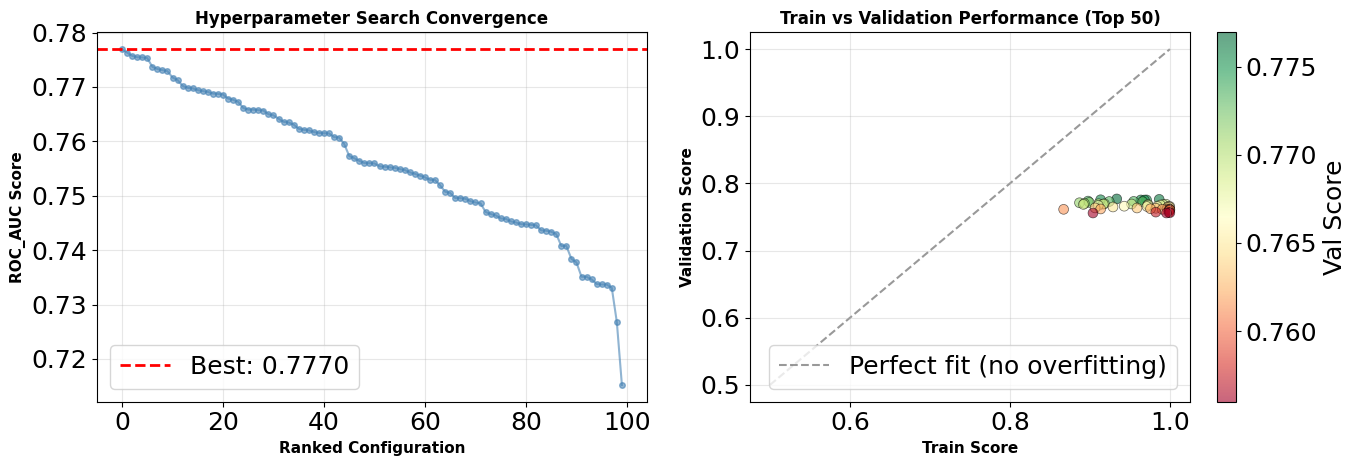

Training Final Model with Optimised Hyeprparameters
------------------------------------------------------------

Training: Optimised Model
Dataset: 203 patients × 28 features
Target: 106 alive (52.2%), 97 died (47.8%)

Running 5-fold stratified cross-validation...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished



                       Cross-Validation Results                       
----------------------------------------------------------------------
Metric          Mean         Std Dev      Range
----------------------------------------------------------------------
ACCURACY        0.7290       ±0.0916      [0.585-0.854]
ROC_AUC         0.7298       ±0.0907      [0.587-0.854]
PRECISION       0.7077       ±0.0983      [0.565-0.850]
RECALL          0.7526       ±0.0661      [0.650-0.850]
F1              0.7287       ±0.0823      [0.605-0.850]


Training final model on full dataset...
✓ Model trained successfully


Optimised Model - SUMMARY

Performance (Cross-Validation):
  AUC-ROC:  0.7298 ± 0.0907
  Accuracy: 0.7290
  F1-Score: 0.7287
  Precision: 0.7077
  Recall:   0.7526

Top 5 Features:
  1. idh1 mutation                                 0.305141
  2. primary diagnosis                             0.120918
  3. age at diagnosis                              0.080198
  4. second progression/

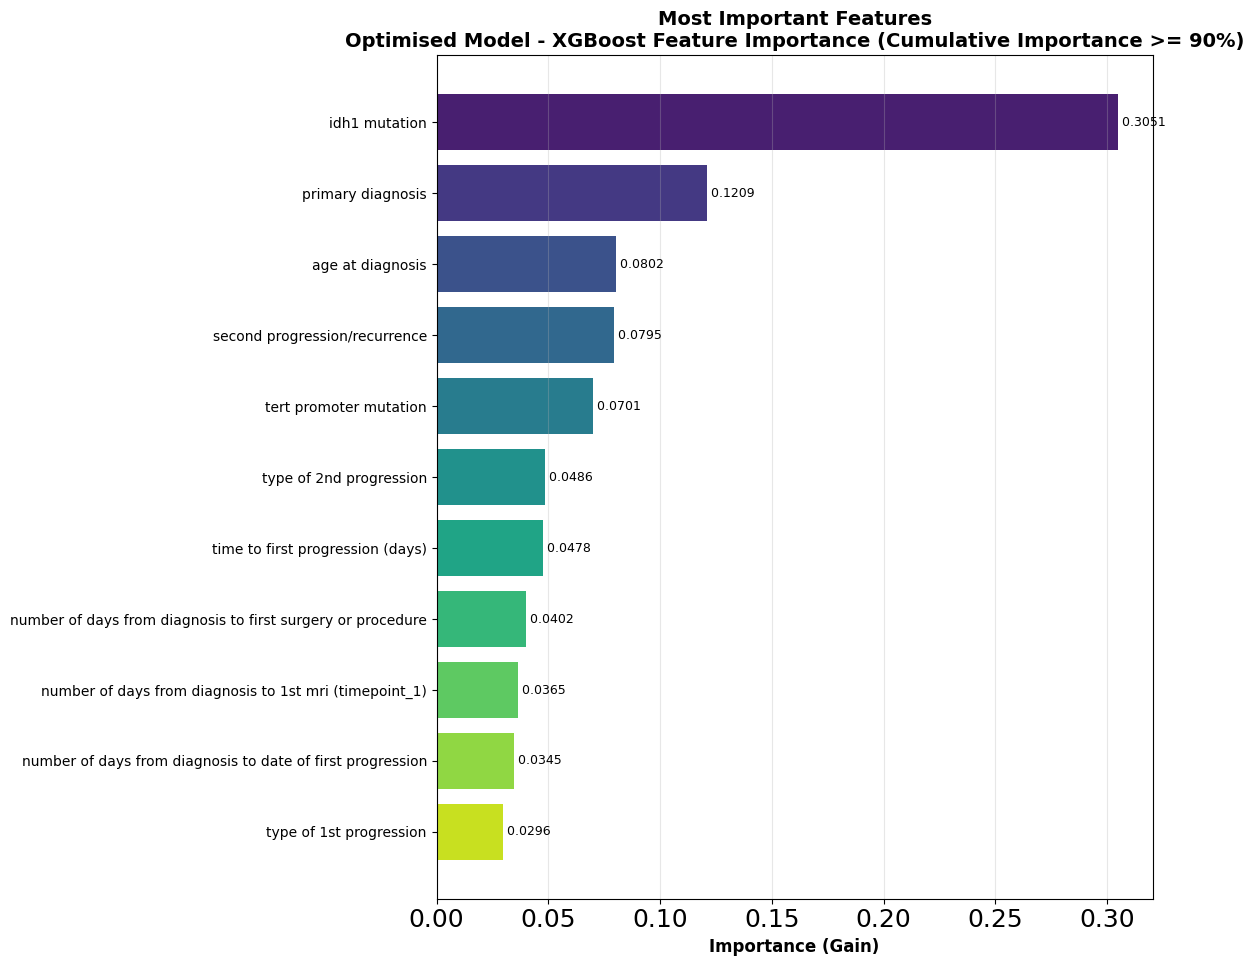


Final Model Ready.
------------------------------
Model name: Optimised Model
Trained on: 25 samples
ROC-AUC: 0.7298 ± 0.0907

Generated outputs:
  📊 hyperparameter_search_results.png & .pdf
  📊 feature_importance_optimised.png & .pdf

Returned objects:
  - model: Trained GliomaBinarySurvivalModel instance
  - random_search: RandomizedSearchCV results



In [41]:
model, search = hyperparameter_search_and_train(
    X, y,
    importance_threshold=0.9,
    n_iter=100
)

## Data Leakage Detection

The baseline model shows signs of overfitting. We check for data leakage by examining feature-target correlations. Features with suspiciously high correlations may represent future information that wouldn't be available at prediction time.

### Encode Categorical Features for Correlation Analysis

In [42]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
label_encoders = {}

for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(label_encoders)} categorical columns for correlation analysis")

Encoded 4 categorical columns for correlation analysis


### Feature-Target Correlation

In [43]:
feature_target_corr = X_encoded.corrwith(y).sort_values(ascending=False)

print("Feature-Target Correlation (sorted by correlation with death)")
print("-"*71)
print(feature_target_corr.to_string())

# Flag suspicious features (|correlation| > 0.25)
threshold = 0.25
suspicious_features = feature_target_corr[abs(feature_target_corr) > threshold].index.tolist()

print(f"\nSuspicious features (|r| > {threshold}): {len(suspicious_features)}")
for f in suspicious_features:
    print(f"  - {f}: {feature_target_corr[f]:.3f}")

Feature-Target Correlation (sorted by correlation with death)
-----------------------------------------------------------------------
age at diagnosis                                               0.334530
second progression/recurrence                                  0.318335
grade of primary brain tumor                                   0.283698
type of 2nd progression                                        0.249142
primary diagnosis                                              0.213954
progression                                                    0.167566
number of days from diagnosis to first surgery or procedure    0.165322
braf v600e mutation                                            0.159967
sex at birth                                                   0.142928
tert promoter mutation                                         0.135791
h3-3a mutation                                                 0.125246
egfr amplification                                             0.112238
ch

### Feature-Feature Correlation for Suspicious Features

In [44]:
if suspicious_features:
    print("Correlation matrix for suspicious features:")
    suspicious_corr = X_encoded[suspicious_features].corr()
    print(suspicious_corr.to_string())

Correlation matrix for suspicious features:
                               age at diagnosis  second progression/recurrence  grade of primary brain tumor  idh1 mutation  idh2 mutation
age at diagnosis                       1.000000                      -0.054454                      0.450825      -0.516191      -0.515133
second progression/recurrence         -0.054454                       1.000000                      0.137051      -0.164538      -0.154604
grade of primary brain tumor           0.450825                       0.137051                      1.000000      -0.534069      -0.621112
idh1 mutation                         -0.516191                      -0.164538                     -0.534069       1.000000       0.864395
idh2 mutation                         -0.515133                      -0.154604                     -0.621112       0.864395       1.000000


### Visualise Correlations

/tmp/ipykernel_262/4049747497.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x='Correlation', y='Feature', palette=bar_colors,


✓ Plot saved to drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/tabular models/figures/02_correlation_analysis.png and drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/tabular models/figures/02_correlation_analysis.pdf


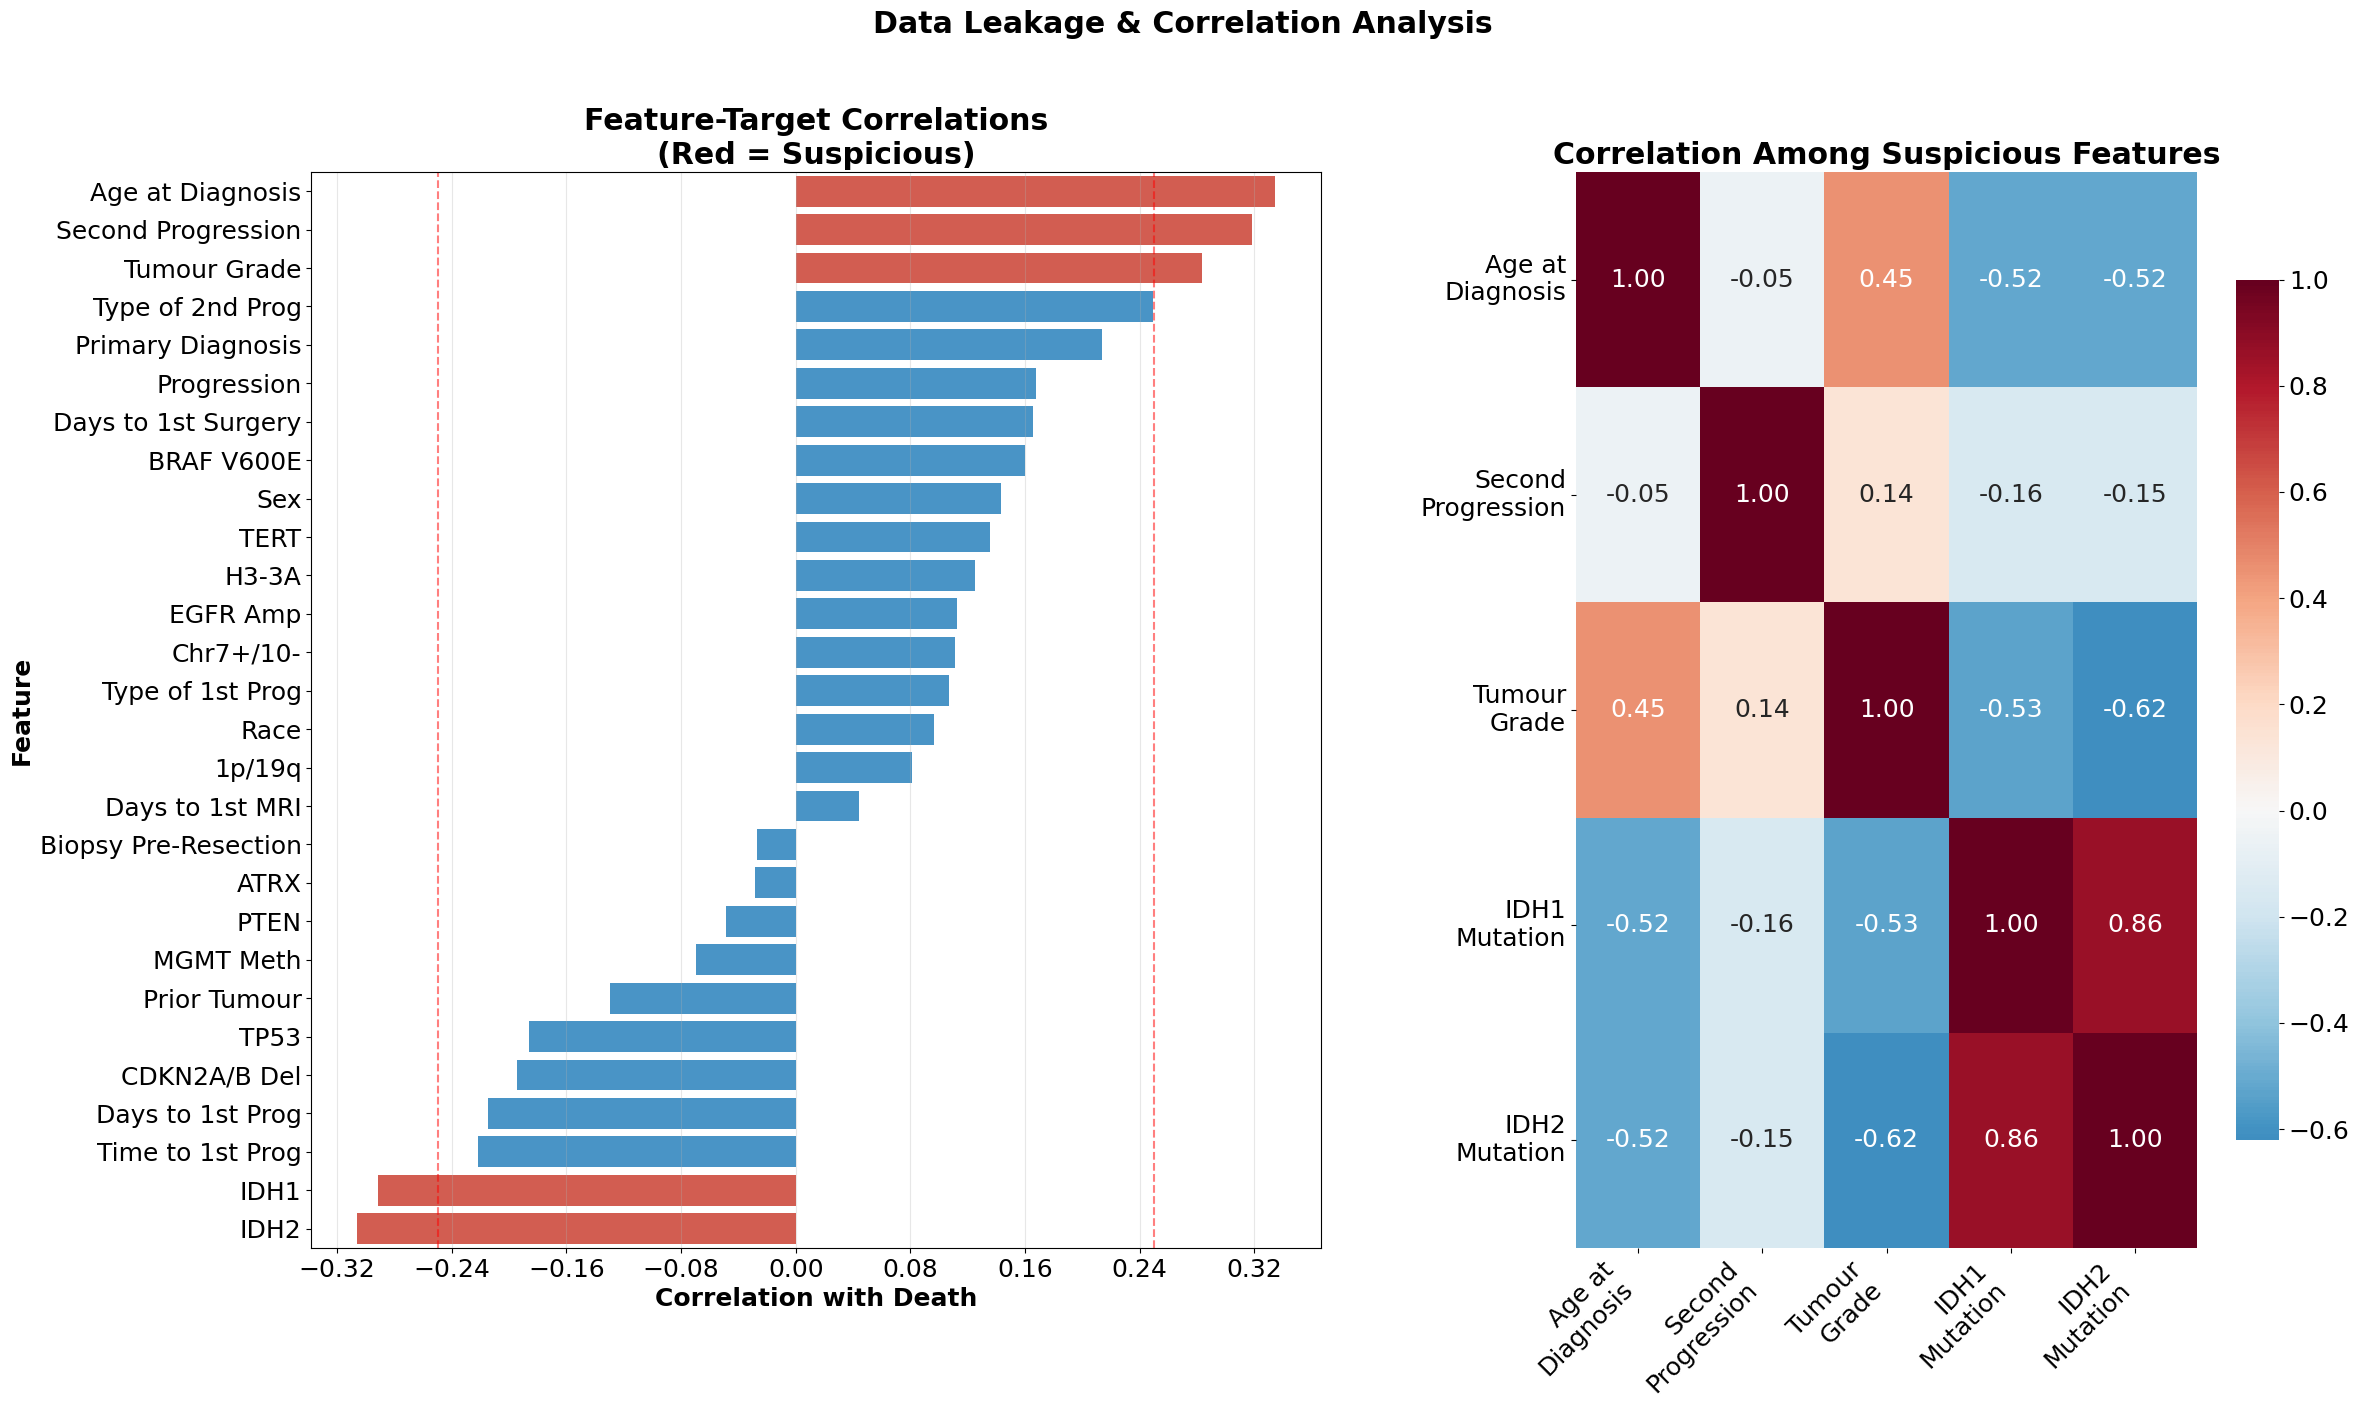

In [45]:
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(1, 2, figsize=(24, 14), gridspec_kw={'width_ratios': [1.3, 1]})
fig.suptitle('Data Leakage & Correlation Analysis', fontweight='bold', y=1.01)

# Short readable names (shared by both plots)
short_names = {
    'age at diagnosis': 'Age at Diagnosis',
    'second progression/recurrence': 'Second Progression',
    'grade of primary brain tumor': 'Tumour Grade',
    'type of 2nd progression': 'Type of 2nd Prog',
    'primary diagnosis': 'Primary Diagnosis',
    'progression': 'Progression',
    'number of days from diagnosis to first surgery or procedure': 'Days to 1st Surgery',
    'braf v600e mutation': 'BRAF V600E',
    'sex at birth': 'Sex',
    'tert promoter mutation': 'TERT',
    'h3-3a mutation': 'H3-3A',
    'egfr amplification': 'EGFR Amp',
    'chromosome 7 gain and chromosome 10 loss': 'Chr7+/10-',
    'type of 1st progression': 'Type of 1st Prog',
    'race': 'Race',
    '1p/19q': '1p/19q',
    'number of days from diagnosis to 1st mri (timepoint_1)': 'Days to 1st MRI',
    'stereotactic biopsy before surgical resection': 'Biopsy Pre-Resection',
    'atrx mutation': 'ATRX',
    'pten mutation': 'PTEN',
    'mgmt methylation': 'MGMT Meth',
    'previous brain tumor': 'Prior Tumour',
    'tp53 alteration': 'TP53',
    'cdkn2a/b deletion': 'CDKN2A/B Del',
    'number of days from diagnosis to date of first progression': 'Days to 1st Prog',
    'time to first progression (days)': 'Time to 1st Prog',
    'idh1 mutation': 'IDH1',
    'idh2 mutation': 'IDH2',
}

# --- Plot 1: Feature-Target Correlations
ax1 = axes[0]
short_labels = [short_names.get(f, f) for f in feature_target_corr.index]
bar_colors = ['#e74c3c' if abs(v) > threshold else '#3498db' for v in feature_target_corr.values]

# Build a DataFrame for seaborn
corr_df = pd.DataFrame({
    'Feature': short_labels,
    'Correlation': feature_target_corr.values
})

sns.barplot(data=corr_df, x='Correlation', y='Feature', palette=bar_colors,
            order=short_labels, ax=ax1, legend=False)
ax1.axvline(x=threshold, color='red', linestyle='--', alpha=0.5)
ax1.axvline(x=-threshold, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Correlation with Death', fontweight='bold')
ax1.set_ylabel('Feature', fontweight='bold')
ax1.xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
ax1.grid(axis='x', alpha=0.3)
ax1.set_title('Feature-Target Correlations\n(Red = Suspicious)', fontweight='semibold', color='black')
# Colour just the subtitle part
ax1.title.set_color('black')

# --- Plot 2: Heatmap of suspicious features
ax2 = axes[1]
if suspicious_features:
    corr_matrix_plot = X_encoded[suspicious_features].corr()

    heatmap_names = {
        'age at diagnosis': 'Age at\nDiagnosis',
        'second progression/recurrence': 'Second\nProgression',
        'grade of primary brain tumor': 'Tumour\nGrade',
        'idh1 mutation': 'IDH1\nMutation',
        'idh2 mutation': 'IDH2\nMutation',
    }
    renamed = [heatmap_names.get(c, c) for c in corr_matrix_plot.columns]
    corr_matrix_plot.columns = renamed
    corr_matrix_plot.index = renamed

    sns.heatmap(corr_matrix_plot, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
                ax=ax2, cbar_kws={'shrink': 0.8})
    ax2.set_title('Correlation Among Suspicious Features', fontweight='semibold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
else:
    ax2.text(0.5, 0.5, 'No suspicious features found', ha='center', va='center', fontweight='bold')

plt.tight_layout(w_pad=4)
png_path_corr = os.path.join(FIGURES_DIR, '02_correlation_analysis.png')
pdf_path_corr = os.path.join(FIGURES_DIR, '02_correlation_analysis.pdf')
plt.savefig(png_path_corr, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path_corr, bbox_inches='tight')
print(f"✓ Plot saved to {png_path_corr} and {pdf_path_corr}")
plt.show()

### Identify Leakage Clusters

In [46]:
if len(suspicious_features) > 0:
    print("Leakage Cluster Analysis")
    print("-"*60)

    # Find highly correlated pairs
    corr_matrix = X_encoded[suspicious_features].corr()
    high_corr_pairs = []

    for idx, feat1 in enumerate(suspicious_features):
        for feat2 in suspicious_features[idx+1:]:
            corr_val = corr_matrix.loc[feat1, feat2]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append((feat1, feat2, corr_val))

    if high_corr_pairs:
        print("\nHighly correlated suspicious feature pairs (|r| > 0.5):")
        for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {f1} <-> {f2}: {corr:.3f}")

Leakage Cluster Analysis
------------------------------------------------------------

Highly correlated suspicious feature pairs (|r| > 0.5):
  idh1 mutation <-> idh2 mutation: 0.864
  grade of primary brain tumor <-> idh2 mutation: -0.621
  grade of primary brain tumor <-> idh1 mutation: -0.534
  age at diagnosis <-> idh1 mutation: -0.516
  age at diagnosis <-> idh2 mutation: -0.515


### Analysis

The correlation analysis reveals two types of high-correlation features:

**Legitimate (biological):** IDH mutations, age, grade, and primary diagnosis cluster together because they reflect known glioma biology.

**Leakage (temporal):** Progression-related features correlate with death because they measure outcomes that occur *after* the prediction timepoint. These must be removed.

## Train Clean Model Without Leakage Features

The 0.25 correlation threshold we set identifies statistically suspicious features but misses some temporal leakage (e.g., progression has r=0.15 but is definitionally future information at time of diagnosis).

As a general rule, leaky features can be identified by answering "Yes" to the following question: "Was this feature known at the time of prediction (diagnosis), or was it measured afterwards?".
In other words, leakage is determined by temporal logic, therefore the final leakage list is defined by whether the feature was available at diagnosis, not by correlation strength alone.

Our leakage analysis identified 7 features that measure **future outcomes** rather than baseline characteristics. We remove these features from X but keep all patients.

In [47]:
leakage_features = [
    'second progression/recurrence',
    'type of 2nd progression',
    'time to first progression (days)',
    'number of days from diagnosis to date of first progression',
    'number of days from diagnosis to first surgery or procedure',
    'progression',
    'type of 1st progression'
]

X_clean = X.drop(columns=leakage_features, errors='ignore').copy()

In [48]:
print(f"Removed {len(leakage_features)} leakage features:")
for f in leakage_features:
    print(f"  - {f}")

print(f"\nRemaining {X_clean.shape[1]} features:")
for f in X_clean.columns:
    print(f"  - {f}")

Removed 7 leakage features:
  - second progression/recurrence
  - type of 2nd progression
  - time to first progression (days)
  - number of days from diagnosis to date of first progression
  - number of days from diagnosis to first surgery or procedure
  - progression
  - type of 1st progression

Remaining 21 features:
  - sex at birth
  - race
  - age at diagnosis
  - primary diagnosis
  - grade of primary brain tumor
  - stereotactic biopsy before surgical resection
  - idh1 mutation
  - idh2 mutation
  - 1p/19q
  - atrx mutation
  - mgmt methylation
  - braf v600e mutation
  - tert promoter mutation
  - chromosome 7 gain and chromosome 10 loss
  - h3-3a mutation
  - egfr amplification
  - pten mutation
  - cdkn2a/b deletion
  - tp53 alteration
  - previous brain tumor
  - number of days from diagnosis to 1st mri (timepoint_1)


In [49]:
y_clean = y.copy()

print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean shape: {y_clean.shape}")
print(f"\nTarget distribution:")
print(f"  Survived: {(y_clean == 0).sum()} ({(y_clean == 0).mean()*100:.1f}%)")
print(f"  Died: {(y_clean == 1).sum()} ({(y_clean == 1).mean()*100:.1f}%)")

X_clean shape: (203, 21)
y_clean shape: (203,)

Target distribution:
  Survived: 106 (52.2%)
  Died: 97 (47.8%)


### Train Clean Model

In [ ]:
model_clean, search_clean = hyperparameter_search_and_train(
    X_clean, y_clean,
    importance_threshold=0.9,
    n_iter=100,
    model_name="Baseline (no leakage)"
)

Initialising Model Optimisation Pipeline via Hyperparameter Search, followed by training a XGBoost Model with the best parameters from cross-val:

Starting Hyperparameter Search
--------------------------------------------------
Dataset: 203 patients × 21 features
Target: 106 alive (52.2%), 97 died (47.8%)

Searching 100 random configurations with 5-fold CV...
Optimising for: ROC_AUC
Fitting 5 folds for each of 100 candidates, totalling 500 fits


The clean model trained successfully. Performance metrics and comparisons will be presented after all model variants are trained.

## Option B: Regularised XGBoost

To address overfitting, we constrain model complexity through more aggressive regularisation. The current hyperparameter search allows:
- Deep trees (max_depth up to 8)
- Many estimators (up to 300)
- Relatively low regularisation

For a dataset of 203 samples with 21 features, these settings permit excessive memorisation. We now search over a more conservative parameter space:
- Shallower trees (max_depth 2-4)
- Fewer estimators (50-100)
- Higher regularisation (gamma, reg_alpha, reg_lambda)
- More aggressive subsampling

### Define Conservative Hyperparameter Space

In [ ]:
param_distributions_conservative = {
    'n_estimators': randint(50, 100),
    'max_depth': randint(2, 5),
    'learning_rate': uniform(0.01, 0.09),
    'subsample': uniform(0.5, 0.3),
    'colsample_bytree': uniform(0.4, 0.4),
    'min_child_weight': randint(5, 15),
    'gamma': uniform(0.5, 2.0),
    'reg_alpha': uniform(0.5, 2.0),
    'reg_lambda': uniform(2.0, 8.0),
    'random_state': [42],
    'enable_categorical': [True],
    'eval_metric': ['logloss']
}

print("Conservative hyperparameter space:")
for param, dist in param_distributions_conservative.items():
    if hasattr(dist, 'args'):
        print(f"  {param}: {dist.args}")
    else:
        print(f"  {param}: {dist}")

### Train Regularised Model

In [ ]:
model_regularised, search_regularised = hyperparameter_search_and_train(
    X_clean, y_clean,
    param_distributions=param_distributions_conservative,
    importance_threshold=0.9,
    n_iter=100,
    model_name="Regularised XGBoost"
)

The regularised model trained successfully. Comparison with other models will follow after Options C and A are implemented.

## Option C: Logistic Regression

As a simpler baseline, we train a logistic regression model. With n=203 samples and 21 features, simpler models often generalise better than complex tree ensembles.

### Train Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Identify numeric and categorical columns
numeric_cols = X_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_clean.select_dtypes(include=['category', 'object']).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')), # Impute missing numerical values
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing categorical values
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns if any, though not expected here
)

# Create full pipeline with logistic regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42))
])

# Cross-validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']

lr_cv_results = cross_validate(
    lr_pipeline, X_clean, y_clean,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("Logistic Regression Cross-Validation Results")
print("-"*44)
for metric in scoring:
    mean_score = np.mean(lr_cv_results[f'test_{metric}'])
    std_score = np.std(lr_cv_results[f'test_{metric}'])
    print(f"{metric.upper():<12} {mean_score:.3f} \u00b1 {std_score:.3f}")

# Fit on full data for later use
lr_pipeline.fit(X_clean, y_clean)

Logistic regression trained successfully.

## Option A: Feature Engineering

We create interaction features based on known glioma biology:
- IDH-wild-type GBM: the worst prognosis subtype
- Elderly GBM: age > 65 with GBM diagnosis
- Molecular risk score: combination of TERT and chromosomal alterations

### Create Engineered Features

In [ ]:
X_engineered = X_clean.copy()

# IDH-wild-type GBM (worst prognosis)
X_engineered['idh_wt_gbm'] = (
    (X_engineered['idh1 mutation'] == 0) &
    (X_engineered['primary diagnosis'] == 'GBM')
).astype(int)

# Elderly GBM (age > 65 with GBM)
X_engineered['elderly_gbm'] = (
    (X_engineered['age at diagnosis'] > 65) &
    (X_engineered['primary diagnosis'] == 'GBM')
).astype(int)

# Molecular risk score
X_engineered['molecular_risk'] = (
    X_engineered['tert promoter mutation'].fillna(0) +
    X_engineered['chromosome 7 gain and chromosome 10 loss'].clip(0, 1)
).astype(int)

# High grade indicator
X_engineered['high_grade'] = (X_engineered['grade of primary brain tumor'] >= 3).astype(int)

print(f"Added 4 engineered features. New shape: {X_engineered.shape}")
print("\nNew features:")
print(f"  idh_wt_gbm: {X_engineered['idh_wt_gbm'].sum()} patients")
print(f"  elderly_gbm: {X_engineered['elderly_gbm'].sum()} patients")
print(f"  molecular_risk distribution: {X_engineered['molecular_risk'].value_counts().to_dict()}")
print(f"  high_grade: {X_engineered['high_grade'].sum()} patients")

### Train Feature-Engineered Model

In [ ]:
model_engineered, search_engineered = hyperparameter_search_and_train(
    X_engineered, y_clean,
    importance_threshold=0.9,
    n_iter=100,
    model_name="Feature-Engineered XGBoost"
)

Feature-engineered model trained successfully.

## Final Model Comparison

We now compare all five models:
1. **Baseline**: XGBoost with all features (including leakage)
2. **Clean**: XGBoost with leakage features removed
3. **Regularised**: XGBoost with conservative hyperparameters
4. **Logistic Regression**: Simple linear model
5. **Feature-Engineered**: XGBoost with domain-informed features

### Performance Comparison Table

In [ ]:
# Collect all results
baseline_results = model.cv_results
clean_results = model_clean.cv_results
regularised_results = model_regularised.cv_results
engineered_results = model_engineered.cv_results

print("Final Model Comparison")
print("-"*135)
print(f"{'Metric':<14} {'Baseline (with leakage)':<25} {'Baseline (no leakage)':<23} {'Regularised XGBoost':<21} {'Logistic Regression':<21} {'Feature-Engineered XGBoost':<28}")
print("-"*135)

for metric in ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']:
    base = f"{np.mean(baseline_results[f'test_{metric}']):.3f} ± {np.std(baseline_results[f'test_{metric}']):.3f}"
    clean = f"{np.mean(clean_results[f'test_{metric}']):.3f} ± {np.std(clean_results[f'test_{metric}']):.3f}"
    reg = f"{np.mean(regularised_results[f'test_{metric}']):.3f} ± {np.std(regularised_results[f'test_{metric}']):.3f}"
    lr = f"{np.mean(lr_cv_results[f'test_{metric}']):.3f} ± {np.std(lr_cv_results[f'test_{metric}']):.3f}"
    eng = f"{np.mean(engineered_results[f'test_{metric}']):.3f} ± {np.std(engineered_results[f'test_{metric}']):.3f}"

    print(f"{metric.upper():<14} {base:<25} {clean:<23} {reg:<21} {lr:<21} {eng:<28}")

print("-"*135)
print("\nNote: 'Baseline (with leakage)' includes leakage features and should not be used for final reporting.")

### ROC Curves

In [ ]:
from matplotlib.gridspec import GridSpec

In [ ]:
# Compute predictions (these are needed by later cells too)
y_pred_baseline = cross_val_predict(model.model, X, y, cv=5, method='predict_proba')[:, 1]
y_pred_clean = cross_val_predict(model_clean.model, X_clean, y_clean, cv=5, method='predict_proba')[:, 1]
y_pred_reg = cross_val_predict(model_regularised.model, X_clean, y_clean, cv=5, method='predict_proba')[:, 1]
y_pred_lr = cross_val_predict(lr_pipeline, X_clean, y_clean, cv=5, method='predict_proba')[:, 1]
y_pred_eng = cross_val_predict(model_engineered.model, X_engineered, y_clean, cv=5, method='predict_proba')[:, 1]

In [ ]:
# Create plots
plt.rcParams.update({'font.size': 18})
fig = plt.figure(figsize=(24, 14))
gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.4)

# Top row: 3 plots
ax_top = [fig.add_subplot(gs[0, 0:2]),
          fig.add_subplot(gs[0, 2:4]),
          fig.add_subplot(gs[0, 4:6])]
# Bottom row: 2 plots centred
ax_bot = [fig.add_subplot(gs[1, 1:3]),
          fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

fig.suptitle('ROC Curves: Model Comparison', fontweight='bold', y=0.98)

roc_data = [
    (y, y_pred_baseline, 'Baseline\n(with leakage)', 'blue'),
    (y_clean, y_pred_clean, 'Baseline\n(no leakage)', 'green'),
    (y_clean, y_pred_reg, 'Regularised\nXGBoost', 'orange'),
    (y_clean, y_pred_lr, 'Logistic\nRegression', 'purple'),
    (y_clean, y_pred_eng, 'Feature-Engineered\nXGBoost', 'red'),
]

for ax, (y_true, y_pred, title, color) in zip(axes, roc_data):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('FPR', fontweight='semibold')
    ax.set_ylabel('TPR', fontweight='semibold')
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(alpha=0.3)

roc_png_path = os.path.join(FIGURES_DIR, '02_roc_curves_comparison.png')
roc_pdf_path = os.path.join(FIGURES_DIR, '02_roc_curves_comparison.pdf')
plt.savefig(roc_png_path, dpi=300, bbox_inches='tight')
plt.savefig(roc_pdf_path, bbox_inches='tight')
print(f"✓ Plot saved to {roc_png_path} and {roc_pdf_path}")
plt.show()

### Confusion Matrices

In [ ]:
plt.rcParams.update({'font.size': 18})
fig = plt.figure(figsize=(24, 14))
gs = GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.4)

# Top row: 3 plots
ax_top = [fig.add_subplot(gs[0, 0:2]),
          fig.add_subplot(gs[0, 2:4]),
          fig.add_subplot(gs[0, 4:6])]
# Bottom row: 2 plots centred
ax_bot = [fig.add_subplot(gs[1, 1:3]),
          fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

fig.suptitle('Confusion Matrices: Model Comparison', fontweight='bold', y=0.98)

models_data = [
    (y, y_pred_baseline, 'Baseline\n(with leakage)', 'Blues'),
    (y_clean, y_pred_clean, 'Baseline\n(no leakage)', 'Greens'),
    (y_clean, y_pred_reg, 'Regularised\nXGBoost', 'Oranges'),
    (y_clean, y_pred_lr, 'Logistic\nRegression', 'Purples'),
    (y_clean, y_pred_eng, 'Feature-Engineered\nXGBoost', 'Reds'),
]

for ax, (y_true, y_pred, title, cmap) in zip(axes, models_data):
    y_pred_class = (y_pred > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_class)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Surv', 'Died'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted label', fontweight='semibold')
    ax.set_ylabel('True label', fontweight='semibold')

    # ConfusionMatrixDisplay renders its own text objects;
    # just bold them, rcParams already set the size to 18
    for text_obj in disp.text_.ravel():
        text_obj.set_fontweight('bold')

cm_png_path = os.path.join(FIGURES_DIR, '02_confusion_matrices.png')
cm_pdf_path = os.path.join(FIGURES_DIR, '02_confusion_matrices.pdf')
plt.savefig(cm_png_path, dpi=300, bbox_inches='tight')
plt.savefig(cm_pdf_path, bbox_inches='tight')
print(f"✓ Plot saved to {cm_png_path} and {cm_pdf_path}")
plt.show()

### Feature Importance Comparison (XGBoost Models)

In [ ]:
plt.rcParams.update({'font.size': 18})

# Rebuild full importance DataFrames
fi_clean = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_clean.model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fi_reg = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_regularised.model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fi_eng = pd.DataFrame({
    'feature': X_engineered.columns,
    'importance': model_engineered.model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

# Shorten feature names for display
short_names = {
    'primary diagnosis': 'Primary\nDiagnosis',
    'idh1 mutation': 'IDH1',
    'idh2 mutation': 'IDH2',
    'age at diagnosis': 'Age at Dx',
    'tert promoter mutation': 'TERT',
    'chromosome 7 gain and chromosome 10 loss': 'Chr7+/10-',
    'grade of primary brain tumor': 'Tumour Grade',
    'number of days from diagnosis to 1st mri (timepoint_1)': 'Days to 1st MRI',
    'stereotactic biopsy before surgical resection': 'Biopsy Pre-Resection',
    'h3-3a mutation': 'H3-3A',
    'tp53 alteration': 'TP53',
    'atrx mutation': 'ATRX',
    'sex at birth': 'Sex',
    'braf v600e mutation': 'BRAF V600E',
    'egfr amplification': 'EGFR Amp',
    'pten mutation': 'PTEN',
    'cdkn2a/b deletion': 'CDKN2A/B Del',
    'mgmt methylation': 'MGMT Meth',
    'previous brain tumor': 'Prior Tumour',
    '1p/19q': '1p/19q',
    'race': 'Race',
    'molecular_risk': 'Molecular Risk',
    'idh_wt_gbm': 'IDH-WT GBM',
    'elderly_gbm': 'Elderly GBM',
    'high_grade': 'High Grade',
}

# Union of all top-10 features across the three models
all_top_features = sorted(
    set(fi_clean['feature']) | set(fi_reg['feature']) | set(fi_eng['feature'])
)

# Build lookup dicts
clean_dict = dict(zip(fi_clean['feature'], fi_clean['importance']))
reg_dict = dict(zip(fi_reg['feature'], fi_reg['importance']))
eng_dict = dict(zip(fi_eng['feature'], fi_eng['importance']))

# Build combined DataFrame, sort by mean importance descending
combined = pd.DataFrame({
    'feature': all_top_features,
    'Baseline (no leakage)': [clean_dict.get(f, 0) for f in all_top_features],
    'Regularised XGBoost': [reg_dict.get(f, 0) for f in all_top_features],
    'Feature-Engineered XGBoost': [eng_dict.get(f, 0) for f in all_top_features],
})
combined['mean'] = combined[['Baseline (no leakage)', 'Regularised XGBoost',
                              'Feature-Engineered XGBoost']].mean(axis=1)
combined = combined.sort_values('mean', ascending=False)
combined = combined.drop(columns='mean')

# Apply short names
combined['label'] = combined['feature'].map(short_names).fillna(combined['feature'])

# Melt into long format for seaborn
melted = combined.melt(
    id_vars=['feature', 'label'],
    value_vars=['Baseline (no leakage)', 'Regularised XGBoost', 'Feature-Engineered XGBoost'],
    var_name='Model',
    value_name='Importance'
)

# Set feature order (top mean importance first, seaborn reads top-to-bottom)
feature_order = combined['label'].tolist()

# Custom palette keyed to model names
palette = {
    'Baseline (no leakage)': 'steelblue',
    'Regularised XGBoost': 'darkorange',
    'Feature-Engineered XGBoost': 'firebrick',
}

fig, ax = plt.subplots(figsize=(14, 12))

sns.barplot(
    data=melted,
    y='label',
    x='Importance',
    hue='Model',
    order=feature_order,
    palette=palette,
    edgecolor='white',
    ax=ax
)

# Add value labels at end of each bar
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        if width > 0:
            ax.text(width + 0.003, bar.get_y() + bar.get_height() / 1.65,
                    f'{width:.3f}', va='center', fontweight='semibold', fontsize=13)

ax.set_xlabel('Importance (Gain)', fontweight='bold')
ax.set_ylabel('')
ax.set_title('Feature Importance Comparison (Top 10 per Model, sorted by Average Importance)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, melted['Importance'].max() * 1.2)

plt.tight_layout()
fi_png_path = os.path.join(FIGURES_DIR, '02_feature_importance.png')
fi_pdf_path = os.path.join(FIGURES_DIR, '02_feature_importance.pdf')
plt.savefig(fi_png_path, dpi=300, bbox_inches='tight')
plt.savefig(fi_pdf_path, bbox_inches='tight')
print(f"✓ Plot saved to {fi_png_path} and {fi_pdf_path}")
plt.show()

### Save All Results

In [ ]:
import json

output_dir = os.path.join(GLIOMA_DIR, 'tabular models', 'results', 'data')
os.makedirs(output_dir, exist_ok=True)

# Save feature importance for each model
fi_clean_full = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_clean.model.feature_importances_
}).sort_values('importance', ascending=False)
fi_clean_full.to_csv(os.path.join(output_dir, '02_feature_importance_clean.csv'), index=False)

fi_reg_full = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_regularised.model.feature_importances_
}).sort_values('importance', ascending=False)
fi_reg_full.to_csv(os.path.join(output_dir, '02_feature_importance_regularised.csv'), index=False)

fi_eng_full = pd.DataFrame({
    'feature': X_engineered.columns,
    'importance': model_engineered.model.feature_importances_
}).sort_values('importance', ascending=False)
fi_eng_full.to_csv(os.path.join(output_dir, '02_feature_importance_engineered.csv'), index=False)

print("Saved feature importance CSVs")

# Save comprehensive comparison
results_summary = {}

# Define common metrics extraction
def extract_metrics(cv_results, X_data):
    return {
        'n_features': int(X_data.shape[1]),
        'auc_mean': float(np.mean(cv_results['test_roc_auc'])),
        'auc_std': float(np.std(cv_results['test_roc_auc'])),
        'accuracy_mean': float(np.mean(cv_results['test_accuracy'])),
        'f1_mean': float(np.mean(cv_results['test_f1']))
    }

# Baseline model (with leakage)
results_summary['baseline'] = extract_metrics(baseline_results, X)
results_summary['baseline']['note'] = 'Includes leakage features - for reference only'

# Baseline model (no leakage)
results_summary['clean'] = extract_metrics(clean_results, X_clean)
results_summary['clean']['features_removed'] = leakage_features

# Regularised model
results_summary['regularised'] = extract_metrics(regularised_results, X_clean)
results_summary['regularised']['note'] = 'Conservative hyperparameters to reduce overfitting'

# Logistic Regression
results_summary['logistic_regression'] = extract_metrics(lr_cv_results, X_clean)
results_summary['logistic_regression']['note'] = 'Simple linear baseline'

# Feature-Engineered model
results_summary['feature_engineered'] = extract_metrics(engineered_results, X_engineered)
results_summary['feature_engineered']['engineered_features'] = ['idh_wt_gbm', 'elderly_gbm', 'molecular_risk', 'high_grade']

with open(os.path.join(output_dir, '02_model_comparison.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Saved 02_model_comparison.json")

## Summary

Five models were trained and compared:

| Model | Description | Features |
|-------|-------------|----------|
| Baseline | XGBoost with all features | 28 (includes leakage) |
| Clean | XGBoost with leakage removed | 21 |
| Regularised | XGBoost with conservative hyperparameters | 21 |
| Logistic Regression | L2-regularised linear model | 21 |
| Feature-Engineered | XGBoost with domain-informed features | 25 |

The baseline model should not be used for reporting as it contains leakage. Among the valid models, performance comparison and interpretation follows in the report.